In [11]:
import scanpy as sc
import pandas as pd
import pathlib
import json
import numpy as np
import anndata
import anndata
import scipy.sparse as sp
import numpy as np
import pandas as pd

In [12]:
_sample = "sample"
_count_type = "count_type"
_suspension = "suspension"
_tissue = "tissue"
_disease = "disease"
_technology = "technology"
_project_id = "project_id"
_technologies = ("10x", "SmartSeq2")
_phase = "phase"
_s_score = "S_score"
_g2m_score = "G2M_score"
_TARGET_SUM = 100_000

results_path = pathlib.Path("data/pretraining")


In [3]:
gene_symbol_map = {}
url = "https://ftp.ncbi.nlm.nih.gov/gene/DATA/GENE_INFO/Mammalia/Homo_sapiens.gene_info.gz"
ncbi = pd.read_table(url)

for idx, row in ncbi[["Symbol", "Synonyms"]].iterrows():
    symbol, synonyms = row["Symbol"], row["Synonyms"]
    gene_symbol_map[symbol] = symbol
    for synonym in synonyms.split("|"):
        if synonym not in gene_symbol_map:
            gene_symbol_map[synonym] = symbol
            
with open("gene_map.json", "w") as f:   
    json.dump(gene_symbol_map, f)    

In [ ]:
def check_adata(adata: sc.AnnData) -> bool:
    expected_columns = set([_suspension, _project_id, _phase, _s_score,_g2m_score, _tissue, _sample, _disease, _technology, 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes'])
    
    if not sp.isspmatrix_csr(adata.X):
        print("adata.X wrong format")
        return False
    
    if not adata.X.dtype == "float32":
        print("adata.X wrong dtype")
        
        return False
    
    if not (set(adata.obs.columns) == expected_columns):
        print("wrong columns")
        return False
    
    if not adata.var_names.is_unique:
        print("Gene names are not unique.")
        return False
    
    if not adata.obs[_suspension].isin(["sc", "sn"]).all():
        print("Suspension unclear for cell")
        return False
    
    return True

def deduplicate_genes(adata: anndata.AnnData) -> anndata.AnnData:
    """
    Deduplicates gene names (var_names) in an AnnData object by summing the expression values of duplicate genes,
    maintaining the sparse matrix format. First, it splits the AnnData into duplicated and non-duplicated genes,
    sums the duplicated genes, and then concatenates the results.
    
    Parameters:
        adata (anndata.AnnData): Input AnnData object with possible duplicate var_names.
    
    Returns:
        anndata.AnnData: New AnnData object with unique var_names and summed expression values.
    """
    # Convert sparse matrix to CSR format for efficient operations
    if not sp.isspmatrix_csr(adata.X):
        adata.X = adata.X.tocsr()
    
    # Identify unique and duplicated genes
    unique_genes, gene_counts = np.unique(adata.var_names, return_counts=True)
    duplicated_genes = unique_genes[gene_counts > 1]
    non_duplicated_genes = unique_genes[gene_counts == 1]
    
    # Split the AnnData object into non-duplicated and duplicated genes
    non_dup_mask = np.isin(adata.var_names, non_duplicated_genes)
    dup_mask = np.isin(adata.var_names, duplicated_genes)
    
    adata_non_dup = adata[:, non_dup_mask]
    #adata_dup = adata[:, dup_mask]
    
    # Sum duplicated genes
    summed_X = []
    var_dup = pd.DataFrame(index=duplicated_genes, columns=["symbol_author"])
    for gene in duplicated_genes:
        gene_mask = adata.var_names == gene
        summed_X.append(adata.X[:, gene_mask].sum(axis=1))
        var_dup.loc[gene, "symbol_author"] = "|".join(adata.var.loc[gene_mask, "symbol_author"].values)
    
    summed_X = sp.csr_matrix(np.hstack(summed_X))
    adata_summed = anndata.AnnData(X=summed_X, obs=adata.obs, var=var_dup)
    
    # Concatenate non-duplicated and summed duplicated genes
    new_adata = anndata.concat([adata_non_dup, adata_summed], axis=1, merge="first", uns_merge="first")
    
    return new_adata


def preprocessing(adata, min_genes: int = 700, max_mt_percent: float = 20., sample_col: str = "sample", min_cells_per_sample: int = 50):
    adata.var['mt'] = adata.var_names.str.lower().str.startswith(('mt-', "mt."))
    sc.pp.calculate_qc_metrics(adata, qc_vars=['mt'], percent_top=None, log1p=False, inplace=True)
    adata = adata[adata.obs['pct_counts_mt'] < max_mt_percent, :].copy()
    sc.pp.filter_cells(adata, min_genes=min_genes)
    if not (sample_col in adata.obs.columns):
        raise IndexError(f"{sample_col} not in adata.obs.columns.")
    sample_counts = adata.obs[sample_col].value_counts()
    
    # Identify samples with enough cells
    valid_samples = sample_counts[sample_counts >= min_cells_per_sample].index
    
    # Keep only cells from valid samples
    adata = adata[adata.obs[sample_col].isin(valid_samples)].copy()
    
    return adata

def score_cell_cycle(adata: sc.AnnData) -> sc.AnnData:
    s_genes = ['MCM5', 'PCNA', 'TYMS', 'FEN1', 'MCM2', 'MCM4', 'RRM1', 'UNG',
               'GINS2', 'MCM6', 'CDCA7', 'DTL', 'PRIM1', 'UHRF1', 'MLF1IP',
               'HELLS', 'RFC2', 'RPA2', 'NASP', 'RAD51AP1', 'GMNN', 'WDR76',
               'SLBP', 'CCNE2', 'UBR7', 'POLD3', 'MSH2', 'ATAD2', 'RAD51', 'RRM2',
               'CDC45', 'CDC6', 'EXO1', 'TIPIN', 'DSCC1', 'BLM', 'CASP8AP2',
               'USP1', 'CLSPN', 'POLA1', 'CHAF1B', 'BRIP1', 'E2F8']

    g2m_genes = ['HMGB2', 'CDK1', 'NUSAP1', 'UBE2C', 'BIRC5', 'TPX2', 'TOP2A',
                 'NDC80', 'CKS2', 'NUF2', 'CKS1B', 'MKI67', 'TMPO', 'CENPF',
                 'TACC3', 'FAM64A', 'SMC4', 'CCNB2', 'CKAP2L', 'CKAP2', 'AURKB',
                 'BUB1', 'KIF11', 'ANP32E', 'TUBB4B', 'GTSE1', 'KIF20B', 'HJURP',
                 'CDCA3', 'HN1', 'CDC20', 'TTK', 'CDC25C', 'KIF2C', 'RANGAP1',
                 'NCAPD2', 'DLGAP5', 'CDCA2', 'CDCA8', 'ECT2', 'KIF23', 'HMMR',
                 'AURKA', 'PSRC1', 'ANLN', 'LBR', 'CKAP5', 'CENPE', 'CTCF', 'NEK2',
                 'G2E3', 'GAS2L3', 'CBX5', 'CENPA']

    sc.tl.score_genes_cell_cycle(adata, s_genes=s_genes, g2m_genes=g2m_genes)
    return adata


def map_gene_names(gene_name):
    if gene_name.startswith("MT-"):
        return gene_name
    if gene_name.startswith("MT."):
        return "MT-" + gene_name[3:]
    
    return gene_symbol_map.get(gene_name, "MISSING")


def normalize_data(adata: sc.AnnData) -> sc.AnnData:
    
    if (sum(np.less(adata.X.data[:100], .75))>50) & (all(np.less(adata.X.data, 100))):
        print(f"Found logp1 transformed data: {adata.X.data[:100]}")
        adata.X.data = np.expm1(adata.X.data)
    sc.pp.normalize_total(adata, target_sum=_TARGET_SUM)
    sc.pp.log1p(adata)
    return adata

def prepare_adata(adata: sc.AnnData) -> sc.AnnData:
    adata.var = adata.var.drop(adata.var.columns, axis=1)
    adata.var["symbol_author"] = adata.var_names
    adata.var_names = adata.var_names.map(map_gene_names)
    adata = adata[:, adata.var_names != "MISSING"].copy()
    adata.obs = adata.obs[[_sample]]
    adata = adata[adata.obs[_sample]!=""].copy()
    adata.obs[_sample] = adata.obs[_sample].astype(str)
    adata.obs[_disease] = row["Disease"]
    adata.obs[_technology] = row["Technology"]
    adata.obs[_tissue] = row["Tissue"]
    adata.obs[_project_id] = row["Project ID"]
    if not adata.var_names.is_unique:
        adata = deduplicate_genes(adata)
    print(adata.X.data[:100])
    adata = preprocessing(adata)
    if adata.n_obs==0:
        return
    adata.obs = adata.obs.merge(suspension, how="left", left_on=[_project_id, _sample], right_on=[_project_id, _sample]).set_axis(adata.obs_names)
    print(adata.obs_names)
    sc.pp.filter_genes(adata, min_cells=1)
    adata = normalize_data(adata)
    score_cell_cycle(adata)
    adata.X = adata.X.astype("float32")
    return adata

In [5]:
url = "https://docs.google.com/spreadsheets/d/1bndaTtNhQe5gPzfEhmeNW_BYSW6m6cF7s4CR-XTDBh4/gviz/tq?tqx=out:csv&sheet=suspension_sample"
suspension = pd.read_csv(url, dtype={_project_id: "str", _sample: "str"})

In [6]:
url = "https://docs.google.com/spreadsheets/d/1bndaTtNhQe5gPzfEhmeNW_BYSW6m6cF7s4CR-XTDBh4/gviz/tq?tqx=out:csv&sheet=Overview"
metadata = pd.read_csv(url, index_col=0)

In [ ]:
data_path = pathlib.Path("data/3ca")
adatas = {}

for index, row in metadata[(metadata["Source"]=="3ca") & (metadata["Include"]=="Yes")].iterrows():
    sample_path = results_path / f"3ca_{index}.h5ad"
    if sample_path.is_file():
        continue
    if not (data_path.joinpath(f"{index}.h5ad").is_file()):
        print(f"Skipped {index}.")
        continue
    adata = sc.read_h5ad(data_path.joinpath(f"{index}.h5ad"))
    
    if "malignant" in adata.obs.columns:
        print("Using malignant annotation.")
        adata = adata[adata.obs["malignant"]=="yes"].copy()
    elif "cell_type" in adata.obs.columns:
        print("Using cell type to determine malignant cells.")
        adata = adata[adata.obs["cell_type"]=="Malignant"].copy()    
    else:
        print(f"{index} is missing celltype annotation.")
        continue

    adata = prepare_adata(adata)
    if adata is None:
        continue
    
    assert check_adata(adata)
    adata.write_h5ad(sample_path)
    
    

In [ ]:
url = "https://docs.google.com/spreadsheets/d/1bndaTtNhQe5gPzfEhmeNW_BYSW6m6cF7s4CR-XTDBh4/gviz/tq?tqx=out:csv&sheet=suspension_sample"
suspension = pd.read_csv(url, dtype={_project_id: "str", _sample: "str"})

data_path = pathlib.Path("data/CancerSCEM")
for index, row in metadata[(metadata["Source"]=="CancerSCEM") & (metadata["Include"]=="Yes")].iterrows():
    project_id = row["Project ID"]
    sample_path = results_path / f"CancerSCEM_{index}.h5ad"
    if sample_path.is_file():
        continue
    if not (data_path.joinpath(f'{project_id.replace("-", "_")}.h5ad').is_file()):
        print(f"Skipped {index}.")
        continue
    adata = sc.read_h5ad(data_path.joinpath(f'{project_id.replace("-", "_")}.h5ad'))
    adata = adata[adata.obs["cell_type"]=="Malignant cells"].copy()
    
    adata = prepare_adata(adata)
    if adata is None:
        continue
    assert check_adata(adata)
    adata.write_h5ad(sample_path)
    

In [ ]:
url = "https://docs.google.com/spreadsheets/d/1bndaTtNhQe5gPzfEhmeNW_BYSW6m6cF7s4CR-XTDBh4/gviz/tq?tqx=out:csv&sheet=suspension_sample"
suspension = pd.read_csv(url, dtype={_project_id: "str", _sample: "str"})


data_path = pathlib.Path("data/cellxgene")
for index, row in metadata[(metadata["Source"].str.startswith("CellxGene")) & (metadata["Include"]=="Yes")].iterrows():
    sample_path = results_path / f"cellxgene_{index}.h5ad"
    if sample_path.is_file():
        continue
    if not (data_path.joinpath(f'{index}.h5ad').is_file()):
        print(f"Skipped {index}.")
        continue
    adata = sc.read_h5ad(data_path.joinpath(f'{index}.h5ad'))
    
    adata = prepare_adata(adata)
    if adata is None:
        continue
    assert check_adata(adata)
    adata.write_h5ad(sample_path)

In [7]:
obs = []

for file_path in pathlib.Path("data/pretraining").iterdir():
    df = sc.read_h5ad(file_path).obs
    df["path"] = file_path.stem
    obs.append(df)
    
obs = pd.concat(obs)


In [16]:
obs["year"] = obs["path"].str.split("_").str[2]

In [18]:
obs["year"].value_counts().sort_index()

year
2016      5213
2017      8620
2018     26354
2019     73507
2020    336070
2021    670886
2022    723123
2023    141663
2024    356790
Name: count, dtype: int64

In [19]:
var_names = []

for file_path in pathlib.Path("data/pretraining").iterdir():
    var_name = sc.read_h5ad(file_path).var_names
    var_names.append(var_name)


In [23]:
from collections import Counter
counts = Counter()

# Iterate through each array in the list
for arr in var_names:
    # Flatten the array in case it's multi-dimensional
    # Update the counter with the counts from this array
    counts.update(arr)
    
    # Convert Counter to a regular dictionary and return


In [29]:
counts = pd.DataFrame(counts, index=["counts"]).T

In [48]:
counts.to_csv("gene_counts.csv")

In [50]:
gene_list = counts.query("counts > 80").index

In [51]:
for file_path in pathlib.Path("data/pretraining").iterdir():
    adata = sc.read_h5ad(file_path)
    adata = adata[:, adata.var_names.isin(gene_list)].copy()
    print(file_path, adata.n_vars)
    adata.write_h5ad(file_path)

data/pretraining/3ca_Wu_2021_breast.h5ad 17018
data/pretraining/3ca_Chan_2021_lung.h5ad 16204
data/pretraining/3ca_Peng_2019_pancreas.h5ad 16302
data/pretraining/3ca_Venteicher_2017_brain.h5ad 16466
data/pretraining/CancerSCEM_Cochrane_2020_othermodels.h5ad 13141
data/pretraining/CancerSCEM_Chen_2023_pancreas.h5ad 16829
data/pretraining/3ca_Lee_2020_colorectal.h5ad 16768
data/pretraining/cellxgene_Johnson_2020_brain.h5ad 16103
data/pretraining/3ca_Qian_2020_ovarian.h5ad 16896
data/pretraining/3ca_He_2021_prostate.h5ad 16380
data/pretraining/CancerSCEM_Yang_2023_colorectal.h5ad 14923
data/pretraining/CancerSCEM_Ganier_2024_skin.h5ad 17070
data/pretraining/3ca_Jerby-Arnon_2018_skin.h5ad 16453
data/pretraining/CancerSCEM_Delgado_2022_breast.h5ad 16428
data/pretraining/3ca_Paulson_2020_skin.h5ad 14312
data/pretraining/3ca_Biermann_2022_skin.h5ad 17169
data/pretraining/CancerSCEM_Vokshi_2023_kidney.h5ad 12256
data/pretraining/3ca_Song_2019_lung.h5ad 9854
data/pretraining/CancerSCEM_Cords_20

In [53]:
obs.to_csv("obs.csv")

In [7]:
import pandas as pd
import seaborn as sns

In [4]:
obs=pd.read_csv("obs.csv", index_col=0)

Text(0.5, 0, '#cells per study')

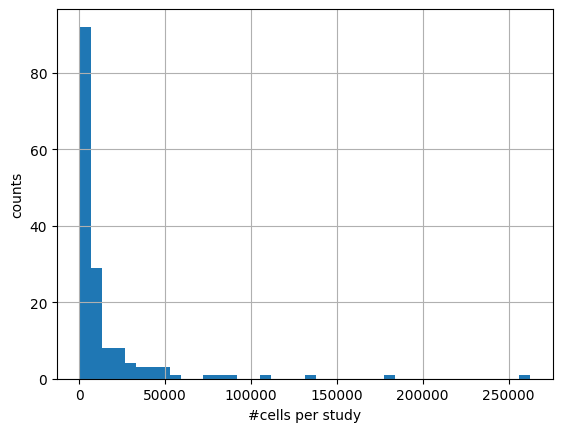

In [36]:
ax = obs[_project_id].value_counts().hist(bins=40)
ax.set_ylabel("counts")
ax.set_xlabel("#cells per study")


In [ ]:
obs["year"].value_counts().to_frame().reset_index()

<Axes: xlabel='year', ylabel='count'>

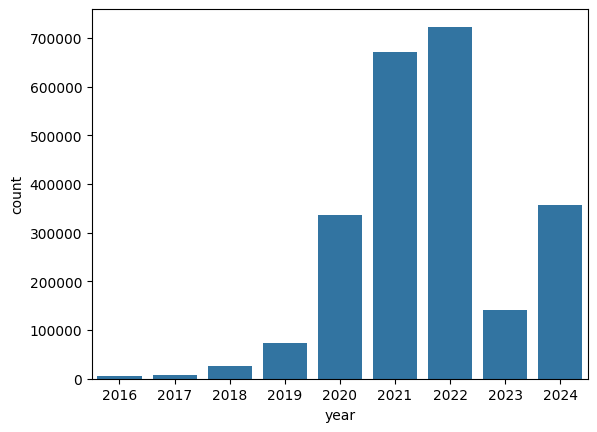

In [29]:
sns.barplot(obs["year"].value_counts().to_frame().reset_index(), y="count", x="year")

<Axes: ylabel='count'>

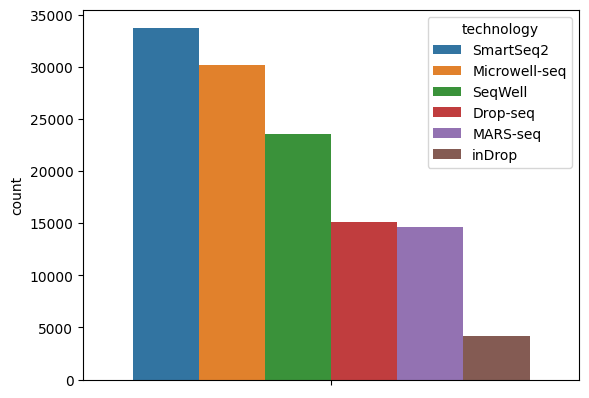

In [26]:
sns.barplot(obs[_technology][obs[_technology]!= "10x"].value_counts().to_frame().reset_index(), y="count", hue=_technology)


In [27]:
obs

,sample,disease,technology,tissue,project_id,n_genes_by_counts,total_counts,total_counts_mt,pct_counts_mt,n_genes,suspension,S_score,G2M_score,phase,path,year
CID3921_ACATCAGAGGGTGTTG,CID3921,Breast cancer,10x,breast,CCCA-77,6400,52071.0,2823.0,5.421443,6400,sc,-0.193748,-0.383066,G1,3ca_Wu_2021_breast,2021
CID3921_ACGATACCATTTGCCC,CID3921,Breast cancer,10x,breast,CCCA-77,1382,4379.0,231.0,5.275177,1382,sc,0.618723,-0.046251,S,3ca_Wu_2021_breast,2021
CID3921_ACGCAGCTCCGCATCT,CID3921,Breast cancer,10x,breast,CCCA-77,6969,60819.0,2427.0,3.990529,6969,sc,0.731245,0.440354,S,3ca_Wu_2021_breast,2021
CID3921_AGAGCTTGTCAAAGCG,CID3921,Breast cancer,10x,breast,CCCA-77,5543,43852.0,4065.0,9.269816,5543,sc,-0.261702,-0.092203,G1,3ca_Wu_2021_breast,2021
CID3921_AGAGTGGTCACTTCAT,CID3921,Breast cancer,10x,breast,CCCA-77,1572,4105.0,117.0,2.850183,1572,sc,0.040924,0.564998,G2M,3ca_Wu_2021_breast,2021
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
P14_TTGGAACTCTGCAGTA-1,P14,Nasopharyngeal carcinoma,10x,head-and-neck,CCCA-1,1750,4184.0,357.0,8.532505,1750,sc,-0.205689,-0.093227,G1,3ca_Chen_2020_head-and-neck,2020
P14_TTGTAGGAGCGATAGC-1,P14,Nasopharyngeal carcinoma,10x,head-and-neck,CCCA-1,2076,7779.0,31.0,0.398509,2076,sc,-0.288955,-0.196884,G1,3ca_Chen_2020_head-and-neck,2020
P14_TTGTAGGAGTCGCCGT-1,P14,Nasopharyngeal carcinoma,10x,head-and-neck,CCCA-1,2756,10869.0,389.0,3.578986,2756,sc,-0.522696,0.375638,G2M,3ca_Chen_2020_head-and-neck,2020
P14_TTTACTGCAATGAATG-1,P14,Nasopharyngeal carcinoma,10x,head-and-neck,CCCA-1,1785,4004.0,563.0,14.060938,1785,sc,-0.352225,-0.411562,G1,3ca_Chen_2020_head-and-neck,2020
